<a href="https://colab.research.google.com/github/mann718/DL-lab/blob/main/lab%203/lab3_cnn_202511046.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install gdown

In [ ]:
!gdown --folder --remaining-ok https://drive.google.com/drive/folders/1u-sBxgNB67GfhCQ2f7xRkDlF6fgIZZrP

In [2]:
import os
import numpy as np
import pandas as pd

In [3]:
# Load the CSV
df = pd.read_csv('/content/drive/MyDrive/DL_Assignment_3/data.csv')
df = df[['Filename', 'AQI_Class']].dropna()
df['AQI_Class'] = df['AQI_Class'].astype(str).str.strip()

print("Total samples:", len(df))
print("\nClass counts:")
print(df['AQI_Class'].value_counts())

Total samples: 6000

Class counts:
AQI_Class
a_Good                              1000
b_Moderate                          1000
c_Unhealthy_for_Sensitive_Groups    1000
d_Unhealthy                         1000
e_Very_Unhealthy                    1000
f_Severe                            1000
Name: count, dtype: int64


In [4]:
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

Using device: cuda


In [5]:
classes = sorted(df['AQI_Class'].unique())
label_map = {c: i for i, c in enumerate(classes)}
inv_map = {i: c for c, i in label_map.items()}
num_classes = len(classes)

print("Classes:", classes)
print("Label map:", label_map)

Classes: ['a_Good', 'b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'e_Very_Unhealthy', 'f_Severe']
Label map: {'a_Good': 0, 'b_Moderate': 1, 'c_Unhealthy_for_Sensitive_Groups': 2, 'd_Unhealthy': 3, 'e_Very_Unhealthy': 4, 'f_Severe': 5}


In [6]:
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=42, stratify=df['AQI_Class'])
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=42, stratify=temp_df['AQI_Class'])

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

Train: 4200  Val: 900  Test: 900


In [7]:
# Custom Dataset
class AQIDataset(Dataset):
    def __init__(self, df, image_root, transform=None):
        self.df = df.reset_index(drop=True)
        self.image_root = image_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = os.path.join(self.image_root, row['Filename'])
        try:
            img = Image.open(path).convert('RGB')
        except:
            img = Image.new('RGB', (224, 224), (128, 128, 128))
        if self.transform:
            img = self.transform(img)
        label = label_map[row['AQI_Class']]
        return img, label

In [8]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

IMAGE_ROOT = '/content/drive/MyDrive/DL_Assignment_3/sampled_images'

train_ds = AQIDataset(train_df, IMAGE_ROOT, train_transform)
val_ds   = AQIDataset(val_df,   IMAGE_ROOT, val_transform)
test_ds  = AQIDataset(test_df,  IMAGE_ROOT, val_transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers = 2)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers = 2)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, num_workers = 2)

print("DataLoaders ready!")

DataLoaders ready!


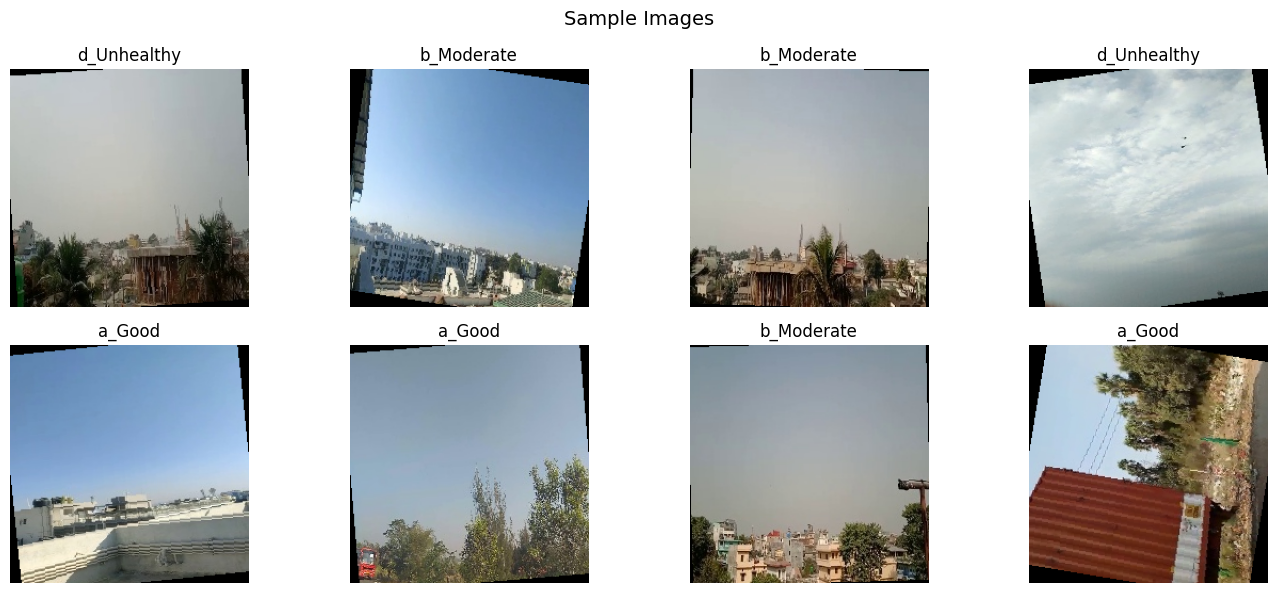

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for i, ax in enumerate(axes):
    idx = np.random.randint(len(train_ds))
    img, label = train_ds[idx]
    # undo normalization
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img = img.permute(1,2,0).clamp(0,1).numpy()
    ax.imshow(img)
    ax.set_title(inv_map[label])
    ax.axis('off')

plt.suptitle('Sample Images', fontsize=14)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100)
plt.show()

In [34]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # Block 4
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

cnn_model = BasicCNN(num_classes).to(device)
total_params = sum(p.numel() for p in cnn_model.parameters())
print(f"Total parameters: {total_params:,}")

# Quick test
dummy = torch.randn(2, 3, 224, 224).to(device)
print("Output shape:", cnn_model(dummy).shape)

Total parameters: 422,086
Output shape: torch.Size([2, 6])


In [35]:
# Training function
def train(model, train_loader, val_loader, epochs=20, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0
    best_weights = None

    for epoch in range(1, epochs+1):
        # --- Train ---
        model.train()
        train_loss = correct = total = 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * imgs.size(0)
            correct += (out.argmax(1) == labels).sum().item()
            total += imgs.size(0)

        # --- Validate ---
        model.eval()
        val_loss = val_correct = val_total = 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                loss = criterion(out, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += (out.argmax(1) == labels).sum().item()
                val_total += imgs.size(0)

        tl = train_loss / total
        ta = correct / total
        vl = val_loss / val_total
        va = val_correct / val_total

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:02d}/{epochs}  Train Loss: {tl:.4f}  Train Acc: {ta*100:.1f}%  Val Loss: {vl:.4f}  Val Acc: {va*100:.1f}%")

    model.load_state_dict(best_weights)
    print(f"\nBest Val Acc: {best_val_acc*100:.2f}%")
    return history

In [45]:
# Train Basic CNN
print("=" * 50)
print("Training Basic CNN...")
print("=" * 50)
cnn_history = train(cnn_model, train_loader, val_loader, epochs=40, lr=1e-3)

Training Basic CNN...
Epoch 01/40  Train Loss: 0.6053  Train Acc: 75.5%  Val Loss: 0.5032  Val Acc: 79.8%
Epoch 02/40  Train Loss: 0.5905  Train Acc: 75.8%  Val Loss: 0.5229  Val Acc: 79.8%
Epoch 03/40  Train Loss: 0.5975  Train Acc: 76.2%  Val Loss: 0.5002  Val Acc: 81.3%
Epoch 04/40  Train Loss: 0.5836  Train Acc: 75.7%  Val Loss: 0.4706  Val Acc: 81.8%
Epoch 05/40  Train Loss: 0.5838  Train Acc: 76.6%  Val Loss: 0.5153  Val Acc: 80.2%
Epoch 06/40  Train Loss: 0.5752  Train Acc: 76.8%  Val Loss: 0.4805  Val Acc: 80.8%
Epoch 07/40  Train Loss: 0.5781  Train Acc: 76.7%  Val Loss: 0.4865  Val Acc: 81.2%
Epoch 08/40  Train Loss: 0.5279  Train Acc: 78.6%  Val Loss: 0.4794  Val Acc: 79.4%
Epoch 09/40  Train Loss: 0.5617  Train Acc: 76.5%  Val Loss: 0.4627  Val Acc: 81.8%
Epoch 10/40  Train Loss: 0.5260  Train Acc: 78.5%  Val Loss: 0.4407  Val Acc: 83.4%
Epoch 11/40  Train Loss: 0.5112  Train Acc: 79.7%  Val Loss: 0.4542  Val Acc: 82.1%
Epoch 12/40  Train Loss: 0.5569  Train Acc: 77.9%  Val

In [46]:
# Evaluate on test set
def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(device)).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

cnn_preds,  cnn_labels  = evaluate(cnn_model, test_loader)

In [47]:
print("=== Basic CNN ===")
print(classification_report(cnn_labels, cnn_preds, target_names=classes, zero_division=0))

=== Basic CNN ===
                                  precision    recall  f1-score   support

                          a_Good       0.80      0.95      0.87       150
                      b_Moderate       0.91      0.85      0.88       150
c_Unhealthy_for_Sensitive_Groups       0.89      0.68      0.77       150
                     d_Unhealthy       0.84      0.95      0.89       150
                e_Very_Unhealthy       0.97      0.93      0.95       150
                        f_Severe       0.94      0.97      0.95       150

                        accuracy                           0.89       900
                       macro avg       0.89      0.89      0.88       900
                    weighted avg       0.89      0.89      0.88       900



In [48]:
# Load pretrained EfficientNet-B0
pretrained_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freeze all backbone layers
for param in pretrained_model.features.parameters():
    param.requires_grad = False

# Replace the classifier head
in_features = pretrained_model.classifier[1].in_features
pretrained_model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, num_classes)
)
pretrained_model = pretrained_model.to(device)

trainable = sum(p.numel() for p in pretrained_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in pretrained_model.parameters())
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}  (head only)")

Total params    : 4,015,234
Trainable params: 7,686  (head only)


In [55]:
# Train Pretrained Model
print("=" * 50)
print("Training Pretrained EfficientNet-B0...")
print("=" * 50)
pt_history = train(pretrained_model, train_loader, val_loader, epochs=40, lr=3e-4)

Training Pretrained EfficientNet-B0...
Epoch 01/40  Train Loss: 0.6739  Train Acc: 75.4%  Val Loss: 0.6031  Val Acc: 80.1%
Epoch 02/40  Train Loss: 0.6691  Train Acc: 76.3%  Val Loss: 0.5931  Val Acc: 80.7%
Epoch 03/40  Train Loss: 0.6490  Train Acc: 77.1%  Val Loss: 0.5850  Val Acc: 81.0%
Epoch 04/40  Train Loss: 0.6534  Train Acc: 77.0%  Val Loss: 0.5856  Val Acc: 80.6%
Epoch 05/40  Train Loss: 0.6522  Train Acc: 77.0%  Val Loss: 0.5841  Val Acc: 80.9%
Epoch 06/40  Train Loss: 0.6461  Train Acc: 77.5%  Val Loss: 0.5835  Val Acc: 81.1%
Epoch 07/40  Train Loss: 0.6384  Train Acc: 77.1%  Val Loss: 0.5745  Val Acc: 81.3%
Epoch 08/40  Train Loss: 0.6373  Train Acc: 77.7%  Val Loss: 0.5678  Val Acc: 80.9%
Epoch 09/40  Train Loss: 0.6266  Train Acc: 77.4%  Val Loss: 0.5725  Val Acc: 81.4%
Epoch 10/40  Train Loss: 0.6399  Train Acc: 76.4%  Val Loss: 0.5649  Val Acc: 81.4%
Epoch 11/40  Train Loss: 0.6416  Train Acc: 76.8%  Val Loss: 0.5592  Val Acc: 81.0%
Epoch 12/40  Train Loss: 0.6280  Trai

In [56]:
pt_preds,   pt_labels   = evaluate(pretrained_model, test_loader)
print("=== Pretrained EfficientNet-B0 ===")
print(classification_report(pt_labels, pt_preds, target_names=classes, zero_division=0))

=== Pretrained EfficientNet-B0 ===
                                  precision    recall  f1-score   support

                          a_Good       0.80      0.77      0.78       150
                      b_Moderate       0.71      0.85      0.77       150
c_Unhealthy_for_Sensitive_Groups       0.76      0.73      0.74       150
                     d_Unhealthy       0.81      0.75      0.78       150
                e_Very_Unhealthy       0.94      0.85      0.89       150
                        f_Severe       0.91      0.95      0.93       150

                        accuracy                           0.82       900
                       macro avg       0.82      0.82      0.82       900
                    weighted avg       0.82      0.82      0.82       900



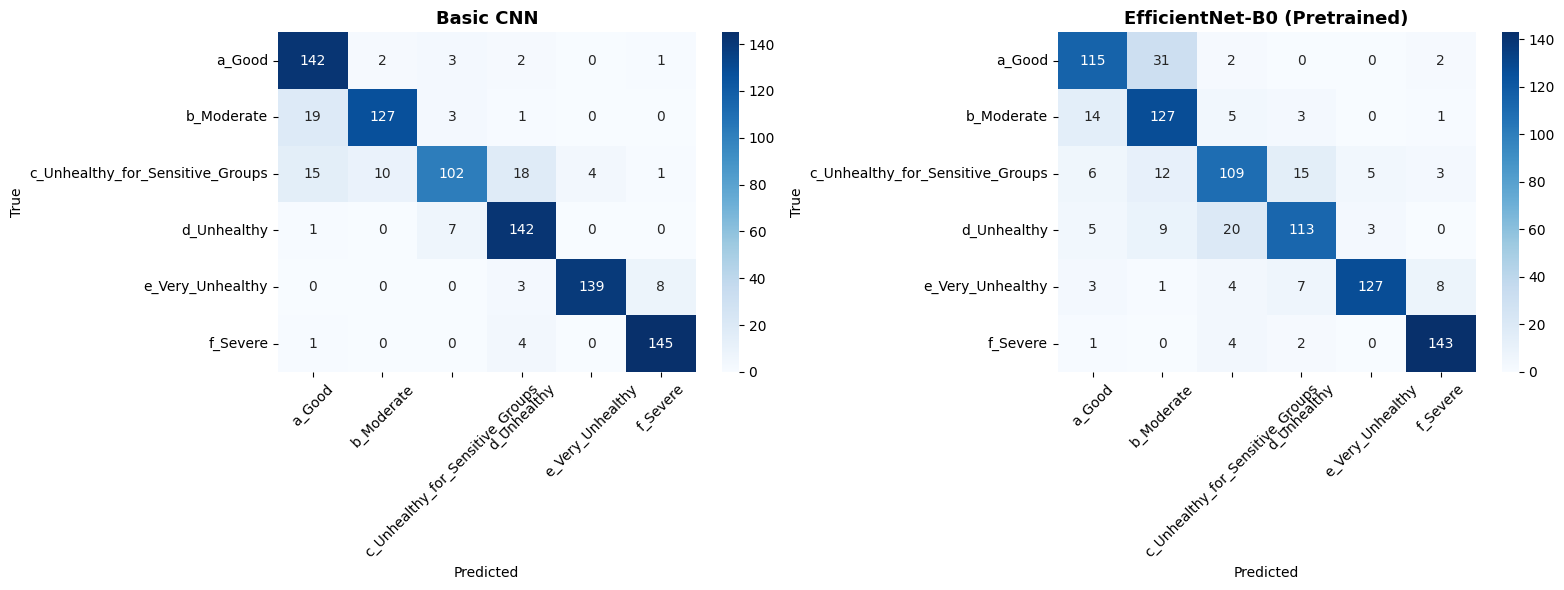

In [57]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, labels, preds, title in zip(
    axes,
    [cnn_labels, pt_labels],
    [cnn_preds,  pt_preds],
    ['Basic CNN', 'EfficientNet-B0 (Pretrained)']
):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

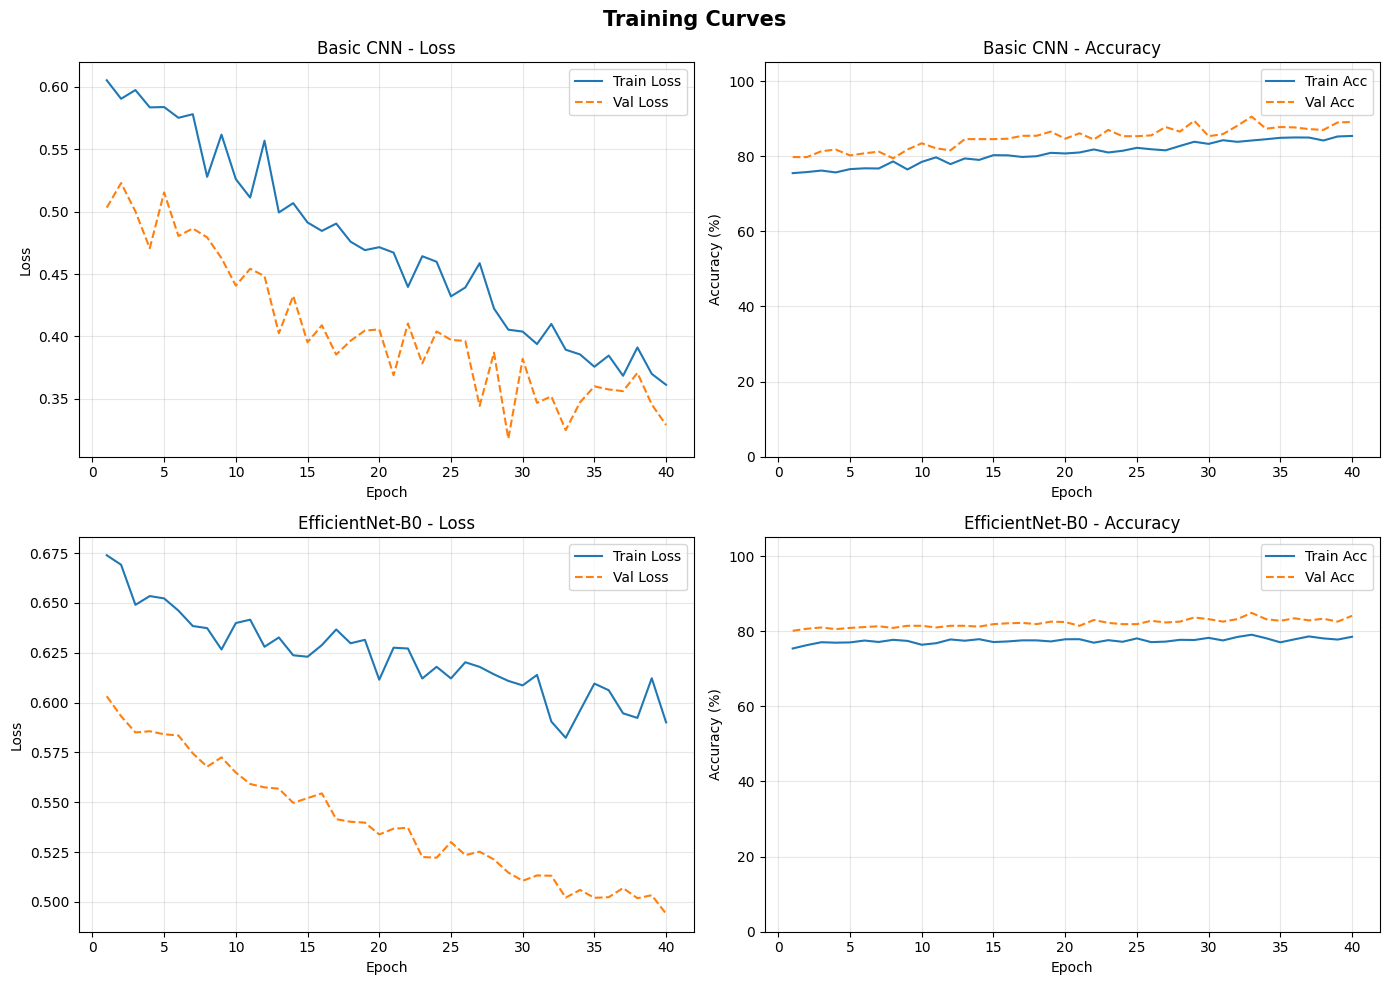

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (hist, name) in enumerate([(cnn_history, 'Basic CNN'), (pt_history, 'EfficientNet-B0')]):
    epochs = range(1, len(hist['train_loss'])+1)

    axes[i][0].plot(epochs, hist['train_loss'], label='Train Loss')
    axes[i][0].plot(epochs, hist['val_loss'],   label='Val Loss', linestyle='--')
    axes[i][0].set_title(f'{name} - Loss')
    axes[i][0].set_xlabel('Epoch'); axes[i][0].set_ylabel('Loss')
    axes[i][0].legend(); axes[i][0].grid(True, alpha=0.3)

    axes[i][1].plot(epochs, [a*100 for a in hist['train_acc']], label='Train Acc')
    axes[i][1].plot(epochs, [a*100 for a in hist['val_acc']],   label='Val Acc', linestyle='--')
    axes[i][1].set_title(f'{name} - Accuracy')
    axes[i][1].set_xlabel('Epoch'); axes[i][1].set_ylabel('Accuracy (%)')
    axes[i][1].set_ylim(0, 105)
    axes[i][1].legend(); axes[i][1].grid(True, alpha=0.3)

plt.suptitle('Training Curves', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

In [59]:
# Get raw images alongside predictions for the pretrained model
all_imgs, all_preds_raw, all_labels_raw = [], [], []

pretrained_model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = pretrained_model(imgs.to(device)).argmax(1).cpu().numpy()
        all_imgs.extend(imgs)
        all_preds_raw.extend(preds)
        all_labels_raw.extend(labels.numpy())

all_imgs       = torch.stack(all_imgs)
all_preds_raw  = np.array(all_preds_raw)
all_labels_raw = np.array(all_labels_raw)

# Find misclassified indices
wrong_idx = np.where(all_preds_raw != all_labels_raw)[0]
print(f"Total misclassified: {len(wrong_idx)} out of {len(all_labels_raw)}")

Total misclassified: 166 out of 900


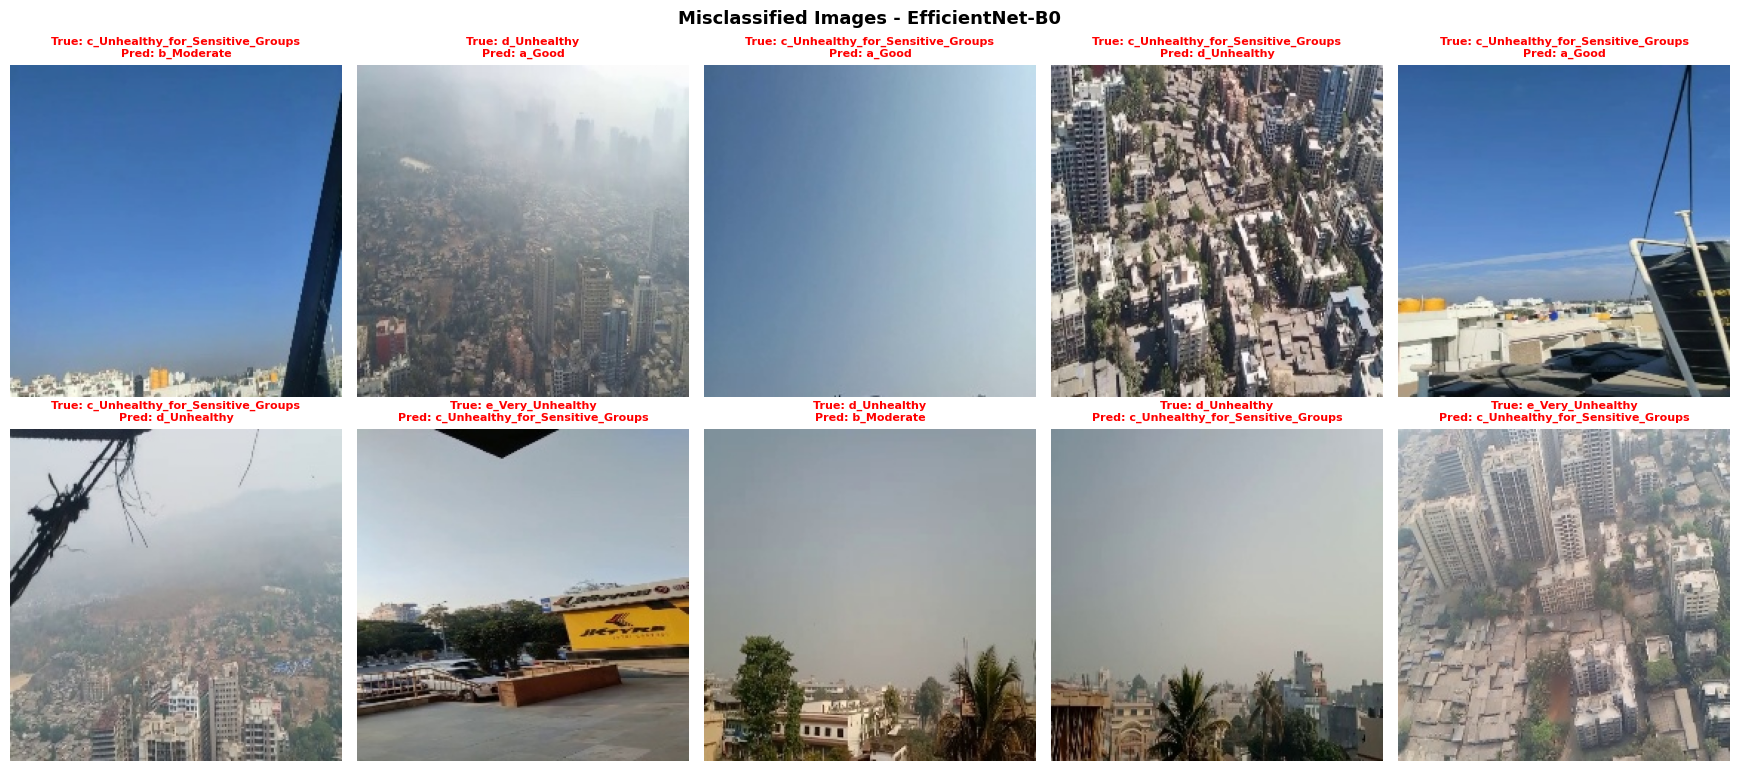

In [60]:
# Show 10 misclassified images
n_show = min(10, len(wrong_idx))
show_idx = wrong_idx[:n_show]

ncols = 5
nrows = (n_show + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*3.5, nrows*4))
axes = axes.flatten()

for ax, idx in zip(axes, show_idx):
    img = all_imgs[idx]
    img = img * torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    img = img + torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    img = img.permute(1,2,0).clamp(0,1).numpy()

    true_label = inv_map[all_labels_raw[idx]]
    pred_label = inv_map[all_preds_raw[idx]]

    ax.imshow(img)
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=8, color='red', fontweight='bold')
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('red'); spine.set_linewidth(2)

for ax in axes[n_show:]:
    ax.set_visible(False)

plt.suptitle('Misclassified Images - EfficientNet-B0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('misclassified.png', dpi=100, bbox_inches='tight')
plt.show()

### Reasons for Misclassification

Looking at the misclassified images, the most common reasons are:

1. **Adjacent AQI classes look very similar** - "Good" vs "Moderate" or "Unhealthy" vs "Very Unhealthy" can look almost identical in photos. The visual difference (slight haze) is subtle.

2. **Lighting and weather effects** - A photo taken on a cloudy day might make a "Good" AQI location look hazier than it is. Bright sunlight can make a "Moderate" location look clearer.

3. **Limited image context** - A single photo doesn't fully capture air quality. The camera angle, zoom level, and background objects can confuse the model.
